# Hyperparameter Optimization (HPO)

## Objective:
In this lab, you will learn to use [Optuna](https://optuna.org/) to fine-tune a [CatBoost](https://catboost.ai/docs/en/concepts/python-quickstart) model on the [Covertype Dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_covtype.html). The objective is to maximize classification accuracy by finding the best hyperparameter combination for this multiclass classification problem.

## 1. Installing Necessary Packages

To get started, install the required Python packages by running the following command in your terminal or command prompt:

```bash
pip install optuna catboost pandas scikit-learn optuna-dashboard seaborn matplotlib
```

What’s Installed:
- Optuna: For hyperparameter optimization.
- CatBoost: The gradient boosting library we’ll tune.
- Pandas: For data manipulation.
- Scikit-learn: For dataset loading and evaluation metrics.
- Optuna-dashboard: For real-time monitoring of optimization.
- Seaborn & Matplotlib: For data visualizations.

## 2. Loading the Covertype Dataset
The Covertype dataset is a multiclass classification task with 54 features, 7 classes, and over 500,000 samples. We’ll load it directly using Scikit-learn’s `fetch_covtype` function.


In [1]:
from sklearn.datasets import fetch_covtype
import pandas as pd

# Load the dataset
covtype = fetch_covtype(as_frame=True)  # Returns a DataFrame
X = covtype.data  # Features
y = covtype.target - 1  # Target (adjusted to 0-6 for zero-based indexing)

In [2]:
X.head(n=10)
X.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.044175,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.205483,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Area_1         

In [4]:
X.select_dtypes(include=['object', 'category']).columns.tolist()

[]

Why Covertype?
- Multiclass Complexity: Predicts 7 forest cover types.
- Mixed Features: Includes both numerical and categorical (binary) features, perfect for CatBoost.
- Large Scale: Tests model performance on a substantial dataset.

To make computations faster, we'll take into account only 20k samples.

In [5]:
sample_size = 20000
# Ensure we get a balanced sample across all classes
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=sample_size, random_state=42, stratify=y
)
X = X_sample
y = y_sample

## 3. Visualizing the Dataset
Visualizations help us understand the data before modeling. Below are three useful plots:

### Class Distribution
Examine the balance of classes in the target variable.

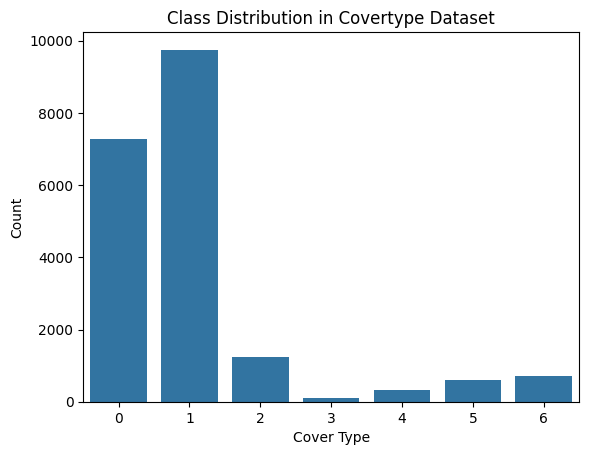

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title('Class Distribution in Covertype Dataset')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

### Feature Correlation Heatmap
Check correlations among the first 10 features.

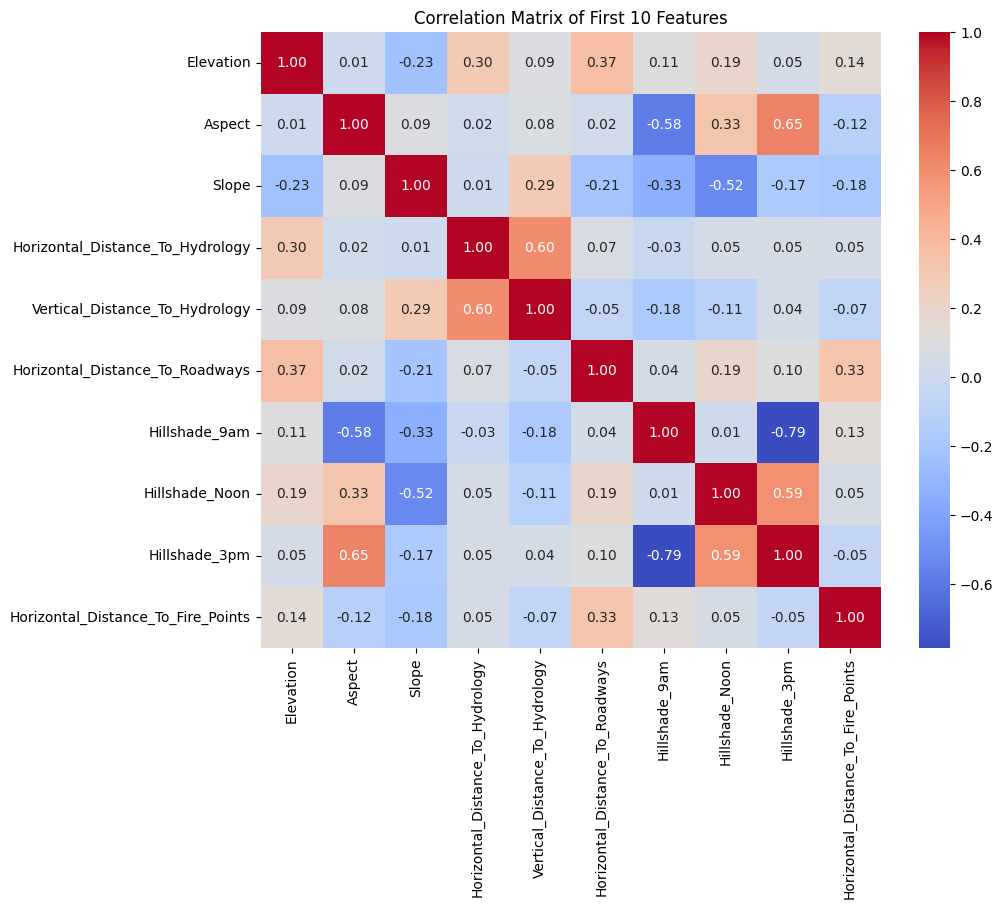

In [7]:
# Select first 10 features for simplicity
subset = X.iloc[:, :10]

# Compute correlation matrix
corr = subset.corr()

plt.figure(figsize=(10, 8))
# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of First 10 Features')
plt.show()

### Pairplot for Selected Features
Visualize relationships between the first 3 features and class separation.

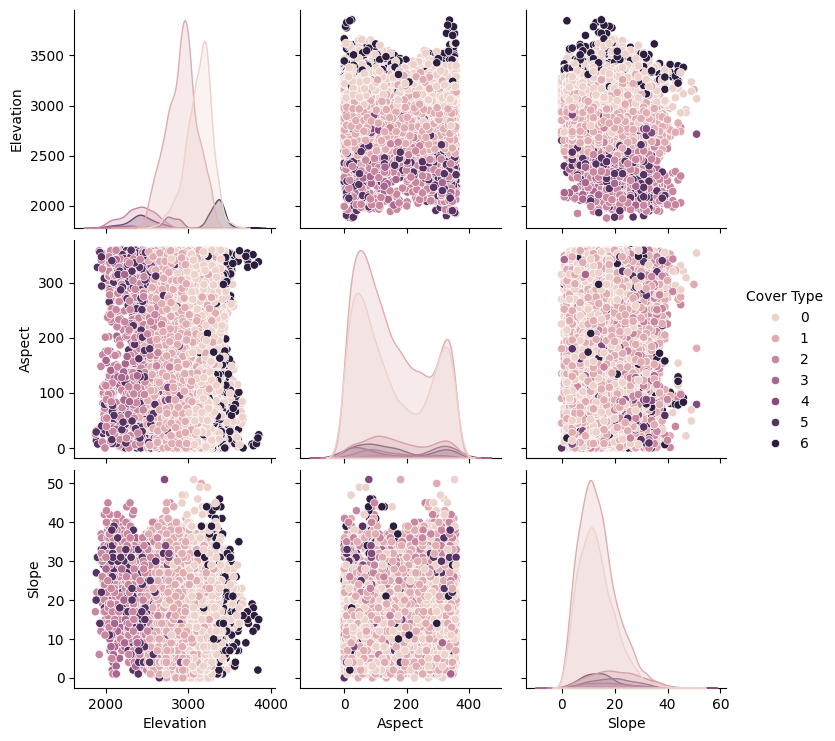

In [8]:
# Combine features and target for a sample
sample = X.iloc[:, :3].copy()  # First 3 features
sample['Cover Type'] = y

sns.pairplot(sample, hue='Cover Type', diag_kind='kde')
plt.show()

## 4. Train and evaluate CatBoost with default settings

Before performing hyperparameter optimization, it’s important to establish a baseline model using CatBoost with default settings. This helps us gauge how much improvement is achieved through tuning.

In [9]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score

# Split the dataset into training, validation and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Initialize the CatBoost model with default settings
model = CatBoostClassifier(verbose=0, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_f1_score = f1_score(y_test, y_pred, average='macro')

print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
print(f"Baseline F1 score: {baseline_f1_score:.2f}")

Baseline Accuracy: 83.43%
Baseline F1 score: 0.72


In [10]:
def calculate_scores(y_test, y_pred):
    baseline_accuracy = accuracy_score(y_test, y_pred)
    baseline_f1_score = f1_score(y_test, y_pred, average='macro')

    print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")
    print(f"Baseline F1 score: {baseline_f1_score:.2f}")

Confusion matrices are great for understanding the model's performance on a per-class basis. They provide detailed insight into which classes are being confused with each other, allowing you to identify weaknesses in the model’s predictions.

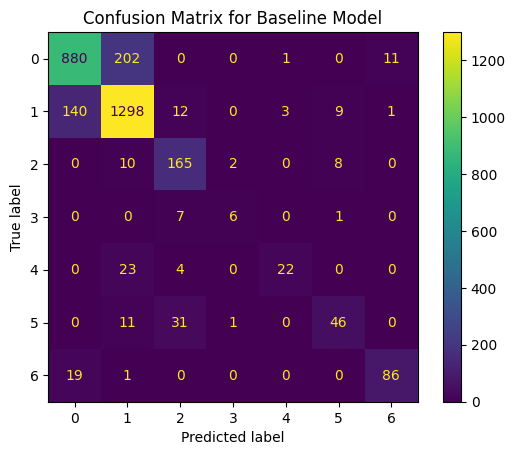

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix for Baseline Model')
plt.show()

## 5. Implementing Hyperparameter Tuning with Optuna
The objective function drives the optimization:
- Takes a trial object from Optuna.
- Suggests hyperparameter values.
- Trains a CatBoost model.
- Evaluates accuracy on the validation set.
- Returns the score (accuracy).

This [notebook](https://github.com/optuna/optuna-examples/blob/main/quickstart.ipynb) provides a useful example of implementing Optuna, although it employs cross-validation (CV) rather than a train/validation split. Additionally, the CatBoost documentation [page](https://catboost.ai/docs/en/concepts/parameter-tuning) offers comprehensive guidance on parameter tuning.

In [14]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 6, 10),
        'l2_leaf_reg': trial.suggest_float('l2_lear_reg', 0.1, 1.0, log=True)
    }

    # 1. Train CatBoost using params
    # 2. Return validation accuracy score as result
    # Area for improvement: use Cross-Validation instead of a single train/val split.

    # clf = CatBoostClassifier(**params, verbose=0, random_state=42)

    # scores = cross_val_score(
    #     clf, X_train, y_train,
    #     cv=3,
    #     scoring='accuracy',
    #     n_jobs=-1
    # )
    # return scores.mean()

    clf = CatBoostClassifier(**params, verbose=0, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_train)
    return accuracy_score(y_train, y_pred)
#

Set up and run the Optuna study:

In [13]:
# Create the study
study_name = 'catboost_optimization'
storage_name = 'sqlite:///example.db'
study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction='maximize',
    load_if_exists=True
)
study.optimize(objective, n_trials=20, show_progress_bar=True)  # Run 20 trials

[I 2026-04-16 09:07:33,096] A new study created in RDB with name: catboost_optimization
Best trial: 0. Best value: 0.777643:   5%|▌         | 1/20 [00:17<05:40, 17.93s/it]

[I 2026-04-16 09:07:51,022] Trial 0 finished with value: 0.7776427885424754 and parameters: {'iterations': 286, 'learning_rate': 0.06702085146063125, 'depth': 6, 'l2_lear_reg': 0.47240293837395486}. Best is trial 0 with value: 0.7776427885424754.


Best trial: 0. Best value: 0.777643:  10%|█         | 2/20 [00:26<03:42, 12.38s/it]

[I 2026-04-16 09:07:59,536] Trial 1 finished with value: 0.733142706449876 and parameters: {'iterations': 106, 'learning_rate': 0.04424158269281576, 'depth': 6, 'l2_lear_reg': 0.47107806403559405}. Best is trial 0 with value: 0.7776427885424754.


Best trial: 0. Best value: 0.777643:  15%|█▌        | 3/20 [01:02<06:31, 23.04s/it]

...

Best trial: 3. Best value: 0.823572:  20%|██        | 4/20 [06:50<40:22, 151.39s/it]

[I 2026-04-16 09:14:23,372] Trial 3 finished with value: 0.8235715237167097 and parameters: {'iterations': 843, 'learning_rate': 0.05663338874907602, 'depth': 9, 'l2_lear_reg': 0.39049333338797104}. Best is trial 3 with value: 0.8235715237167097.


Best trial: 3. Best value: 0.823572:  20%|██        | 4/20 [08:05<32:20, 121.26s/it]


[W 2026-04-16 09:15:38,154] Trial 4 failed with parameters: {'iterations': 404, 'learning_rate': 0.024388521578718382, 'depth': 9, 'l2_lear_reg': 0.7219062484097803} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\User\miniconda3\envs\umisi\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Temp\ipykernel_20740\4049305637.py", line 18, in objective
    scores = cross_val_score(
             ^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py", line 684, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^^^^
  File "C:\

KeyboardInterrupt: 

## 6. Setting up Optuna Dashboard
Optuna offers a dashboard to monitor optimization in real-time. Launch it with:
```bash
optuna-dashboard sqlite:///example.db
```

Monitor trials at http://localhost:8080. Discuss results. Which features are most important?

## 7. Post-Optimization Steps: Analyzing Results and Final Evaluation

After the Optuna study completes, we need to analyze the results, train a final model using the best hyperparameters found, and evaluate its performance on the unseen test set.

In [ ]:
# Retrieve the best trial from the study
best_trial = study.best_trial

print(f"Best Trial Number: {best_trial.number}")
print(f"Best Validation Accuracy: {best_trial.value:.4f}")
print("Best Hyperparameters Found:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

ValueError: Record does not exist.

> Note: Review the best hyperparameters found. Do they make sense? Are any parameters hitting the boundaries of their search space (e.g., iterations consistently at 1000)? If so, you might consider expanding the search space in a future run. The "Best Validation Accuracy" is the score Optuna maximized using the validation set within the objective function.

Now, we train a new CatBoost model using the best hyperparameters found by Optuna. Crucially, we train this model on the combination of the original training data and validation data. This allows the final model to learn from more data than any single model trained during the optimization trials.

In [ ]:
best_params = best_trial.params

# --- IMPORTANT: Combine Training and Validation Data ---
# Create the full training dataset (train + validation) for the final model
X_train_full = pd.concat([X_train, X_valid], ignore_index=True)
y_train_full = pd.concat([y_train, y_valid], ignore_index=True)

final_params = best_params.copy()
final_params['random_state'] = 42

final_model = CatBoostClassifier(**final_params)
final_model.fit(X_train_full, y_train_full)

This is the moment of truth! We evaluate our optimized `final_model` on the completely unseen X_test and y_test to get an unbiased estimate of its generalization performance. We then compare this to the baseline model's performance on the same test set.

In [ ]:
y_pred_test = final_model.predict(X_test)

# Calculate final accuracy
final_accuracy = accuracy_score(y_test, y_pred_test)

print("--- Performance Comparison ---")
# Assuming baseline_accuracy variable holds the score from Step 5
print(f"Baseline Accuracy (on Test Set): {baseline_accuracy * 100:.2f}%")
print(f"Optimized Accuracy (on Test Set): {final_accuracy * 100:.2f}%")
improvement = final_accuracy - baseline_accuracy
print(f"Improvement due to HPO: {improvement * 100:.2f}%")

print("Confusion Matrix for Final Optimized Model (on Test Set):")
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title('Confusion Matrix for Final Optimized Model')
plt.tight_layout()
plt.show()

In [ ]:
calculate_scores(y_test, y_pred_test)

Finally, let's examine which features the optimized CatBoost model found most important for making predictions.

In [ ]:
importances = final_model.get_feature_importance()
feature_names = X_train_full.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances (e.g., top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20)) # Plot top 20
plt.title('Top 20 Feature Importances from Final Optimized Model')
plt.tight_layout()
plt.show()